In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Import data (Make sure to parse dates. Consider setting index column to 'date'.)

In [104]:
df = pd.read_csv('fcc-forum-pageviews.csv')

In [105]:
df['date'] = pd.to_datetime(df['date'])

In [106]:
df

,date,value
0,2016-05-09,1201
1,2016-05-10,2329
2,2016-05-11,1716
3,2016-05-12,10539
4,2016-05-13,6933
...,...,...
1299,2019-11-29,171584
1300,2019-11-30,141161
1301,2019-12-01,142918
1302,2019-12-02,220144


# Clean data

In [107]:
#df = None

df['value']

0         1201
1         2329
2         1716
3        10539
4         6933
         ...  
1299    171584
1300    141161
1301    142918
1302    220144
1303    158549
Name: value, Length: 1304, dtype: int64

In [108]:
df['value'].describe()

count    1.304000e+03
mean     6.722068e+04
std      5.933964e+04
min      1.201000e+03
25%      3.575775e+04
50%      5.719750e+04
75%      8.388300e+04
max      1.173655e+06
Name: value, dtype: float64

In [109]:
df['value'].mean()

67220.68328220859

In [110]:
df['value'].quantile()

57197.5

In [111]:
df['value'].describe()

count    1.304000e+03
mean     6.722068e+04
std      5.933964e+04
min      1.201000e+03
25%      3.575775e+04
50%      5.719750e+04
75%      8.388300e+04
max      1.173655e+06
Name: value, dtype: float64

In [112]:
# 2.5 percentage of data 
df['value'].quantile(0.025)

17876.4

In [113]:
#97.5 percentage of data 
df['value'].quantile(0.975)

177613.075

In [114]:
bigger_percentage = df['value'] < df['value'].quantile(0.025)
smaller_percentage = df['value'] > df['value'].quantile(0.975)

In [115]:
sil_1 = df.loc[bigger_percentage]

In [116]:
sil_2 = df.loc[smaller_percentage]

In [117]:
df.drop(sil_1.index , inplace=True)
df.drop(sil_2.index , inplace=True)

In [118]:
df

,date,value
10,2016-05-19,19736
17,2016-05-26,18060
18,2016-05-27,19997
19,2016-05-28,19044
20,2016-05-29,20325
...,...,...
1294,2019-11-24,138875
1299,2019-11-29,171584
1300,2019-11-30,141161
1301,2019-12-01,142918


In [136]:
my_filter = pd.to_datetime(df.date).dt.month
my_filter

10       5
17       5
18       5
19       5
20       5
        ..
1294    11
1299    11
1300    11
1301    12
1303    12
Name: date, Length: 1238, dtype: int64

In [137]:
df.groupby(my_filter).sum()

,value
date,
1,5996075
2,5677292
3,5681598
4,5477940
5,5746821
6,6358660
7,7603503
8,7368193
9,7561927


In [132]:
gr.sum()

,value
date,
2016-05-19,19736
2016-05-26,18060
2016-05-27,19997
2016-05-28,19044
2016-05-29,20325
...,...
2019-11-24,138875
2019-11-29,171584
2019-11-30,141161


In [139]:
df_box = df.copy()
df_box.reset_index(inplace=True)
df_box['year'] = [d.year for d in df_box.date]
df_box['month'] = [d.strftime('%b') for d in df_box.date]

In [140]:
df_box

,index,date,value,year,month
0,10,2016-05-19,19736,2016,May
1,17,2016-05-26,18060,2016,May
2,18,2016-05-27,19997,2016,May
3,19,2016-05-28,19044,2016,May
4,20,2016-05-29,20325,2016,May
...,...,...,...,...,...
1233,1294,2019-11-24,138875,2019,Nov
1234,1299,2019-11-29,171584,2019,Nov
1235,1300,2019-11-30,141161,2019,Nov
1236,1301,2019-12-01,142918,2019,Dec


In [159]:
bardata = df_box.groupby(by='month').sum()

In [160]:
bardata

,index,value,year
month,,,
Apr,63585,5477940,181620
Aug,77797,7368193,246132
Dec,57102,5146782,191619
Feb,54306,5677292,169512
Jan,57381,5996075,187674
Jul,74929,7603503,242103
Jun,67606,6358660,215886
Mar,62868,5681598,187674
May,68625,5746821,197754


<AxesSubplot:xlabel='month', ylabel='value'>

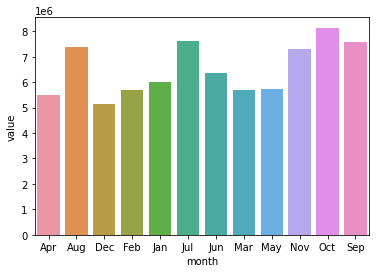

In [161]:
sns.barplot(x = bardata.index,y=bardata['value'])